#Protein Structure Analysis with Transformers


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdb
import seaborn as sns

In [ ]:
!pip install py3Dmol

In [ ]:
##Display Prot with known structure
import py3Dmol
#view = py3Dmol.view(query='pdb:1CRN')  # example PDB ID
#view.setStyle({'cartoon': {'color':'spectrum'}})
#view.zoomTo()
#view.show()

### Get Fasta File

In [ ]:
import re

def parse_record(header, seq_lines):
    sequence = "".join(seq_lines)
    header = header[1:]

    parts = header.split()
    id_part = parts[0]
    db, accession, name = id_part.split("|")

    # Extract full OS= field
    organism_match = re.search(r"OS=(.*?) OX=", header)
    organism = organism_match.group(1) if organism_match else None

    return {
        "id": id_part,
        "accession": accession,
        "name": name,
        "organism": organism,
        "sequence": sequence
    }


def read_uniprot_fasta(filepath):
  """
  Reads UniProt-style FASTA file.

  Returns:
      records: list of dictionaries with keys:
          - id
          - accession
          - name
          - organism
          - sequence
  """

  records = []

  with open(filepath, "r") as f:
      current_header = None
      current_seq = []

      for line in f:
          line = line.strip()

          if line.startswith(">"):
              # Save previous record
              if current_header is not None:
                  records.append(parse_record(current_header, current_seq))

              current_header = line
              current_seq = []

          else:
              current_seq.append(line)

      # Save last record
      if current_header is not None:
          records.append(parse_record(current_header, current_seq))

  return records

In [ ]:
records = read_uniprot_fasta("uniprot_sprot.fasta")
print(records[0]["accession"])
print(records[0]["organism"])
print(records[0]["sequence"][:20])
print("Total Records: ",len(records))

Q6GZX4
Frog virus 3 (isolate Goorha)
MAFSAEDVLKEYDRRRRMEA
Total Records:  574627


In [ ]:
def loadSequences(records, loadN):
  seq = []
  nloaded = 0
  for r in records:
    if nloaded<loadN:
      if (len(r['sequence'])<450):
        seq.append(r['sequence'])
        nloaded +=1

  print("Seq loaded: ",nloaded)
  return seq

#Get sequences
aa = loadSequences(records,20000)
from sklearn.model_selection import train_test_split
aa_train,aa_test = train_test_split(aa,test_size=0.2)
print(f"Train:{len(aa_train):4d} Test:{len(aa_test):4d}")

Seq loaded:  20000
Train:16000 Test:4000


In [ ]:
##The above seqeunce is STRUCTURE OF AZURIN FROM ALCALIGENES DENITRIFICANS (rcsb.org)
## pdb:1RHS
view = py3Dmol.view(query='pdb:2AZA')  # example PDB ID
view.setStyle({'cartoon': {'color':'spectrum'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Sequence Min/Avg/Max:  3 265.585875 449


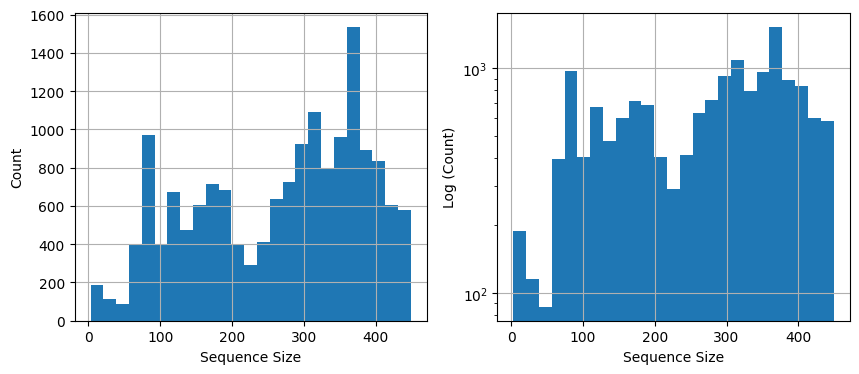

In [ ]:
##Plot data
aa_train = [list(a) for a in aa_train]
seq_sizes =[]
for i in aa_train:
  seq_sizes.append(len(i))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(seq_sizes,bins=25)
axes[0].set_xlabel("Sequence Size")
axes[0].set_ylabel("Count")
axes[0].grid(True)

##
axes[1].hist(seq_sizes,bins=25)
axes[1].set_xlabel("Sequence Size")
axes[1].set_ylabel("Log (Count)")
axes[1].set_yscale("log")
axes[1].grid(True)

print("Sequence Min/Avg/Max: ",np.min(seq_sizes),np.mean(seq_sizes),np.max(seq_sizes))

In [ ]:
##Check AA residue frequency
from collections import Counter, OrderedDict
from itertools import chain

# Flatten the list of lists
flat_data = list(chain.from_iterable(aa_train))


# Count frequencies
global_freq = Counter(flat_data)
global_freq = OrderedDict(sorted(global_freq.items()))
print(global_freq)

normalized_freq_by_size = {}
total_aa = 0
for size, counter in global_freq.items():
    #print (size,counter)
    total_aa += counter

normalized_freq_by_size = {k: v / total_aa for k, v in global_freq.items()}
print (normalized_freq_by_size)

OrderedDict({'A': 381216, 'B': 3, 'C': 62051, 'D': 234366, 'E': 276924, 'F': 157091, 'G': 332945, 'H': 99914, 'I': 268999, 'K': 230073, 'L': 415951, 'M': 109771, 'N': 158142, 'P': 194579, 'Q': 150290, 'R': 223589, 'S': 254084, 'T': 228779, 'V': 301265, 'W': 45759, 'X': 141, 'Y': 123441, 'Z': 1})
{'A': 0.08971109626970937, 'B': 7.059863405762826e-07, 'C': 0.014602386139699636, 'D': 0.055153064898500345, 'E': 0.06516818712591549, 'F': 0.03696803340915627, 'G': 0.0783515407210568, 'H': 0.023512639744112898, 'I': 0.06330320654289315, 'K': 0.054142798445135684, 'L': 0.09788524144968176, 'M': 0.02583227553046637, 'N': 0.037215363957138155, 'P': 0.045790038720997496, 'Q': 0.035367562375069835, 'R': 0.05261692663437015, 'S': 0.05979327778632806, 'T': 0.05383828300356711, 'V': 0.07089632496457125, 'W': 0.010768409652810038, 'X': 3.318135800708528e-05, 'Y': 0.029049219955692297, 'Z': 2.3532878019209418e-07}


(0.0, 0.1)

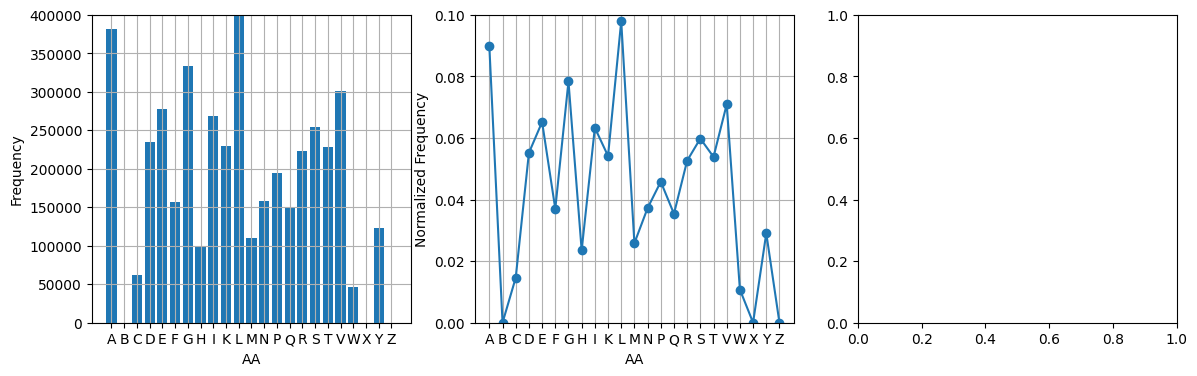

In [ ]:
aa_labels = list(global_freq.keys())
aa_freq   = list(global_freq.values())
aa_freq_n = list(normalized_freq_by_size.values())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(aa_labels,aa_freq)
axes[0].set_xlabel("AA")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)
axes[0].set_ylim(0,400000)
##
axes[1].plot(aa_labels,aa_freq_n, marker='o')
axes[1].set_xlabel("AA")
axes[1].set_ylabel("Normalized Frequency")
axes[1].grid(True)
axes[1].set_ylim(0,0.1)

In [ ]:
##Create token dictionary
unq_aa = global_freq.keys()
#d_atoidx = {j : i for i,j in enumerate(unq_aa)}
#d_idxtoa = {i : j for i,j in enumerate(unq_aa)}
#print(d_atoidx); print(d_stoidx); print(d_idxtoa);print(d_idxtos)

def build_token_dict():
    amino_acids    = list(unq_aa)
    special_tokens = ["[PAD]", "[CLS]", "[MASK]"]
    ## Combine special + amino acids
    vocab = special_tokens + amino_acids
    ##
    token2idx = {token: idx for idx, token in enumerate(vocab)}
    idx2token = {idx: token for token, idx in token2idx.items()}
    return token2idx, idx2token


token2idx, idx2token = build_token_dict()
print(token2idx)

{'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, 'A': 3, 'B': 4, 'C': 5, 'D': 6, 'E': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'K': 12, 'L': 13, 'M': 14, 'N': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


In [ ]:
###Functions
##Create tokens
import random

def encode_sequence(sequence, token2idx):
    """
    Converts protein string into token IDs with CLS token.
    """
    tokens = ["[CLS]"] + list(sequence)

    return [token2idx[token] for token in tokens]

##Create masked sample
def create_masked_sample(sequence, token2idx,pMask):
    """
    Creates one masked training sample from a protein sequence.
    Exactly one residue is masked.
    """
    encoded = encode_sequence(sequence, token2idx)

    # Do not mask CLS (index 0)
    pMask = int(len(encoded)*pMask)
    enc_ids  = [i for i in range(1,len(encoded)-1)]
    #print("pMask enc_ids",pMask, enc_ids)
    mask_positions = random.sample(enc_ids,pMask)
    #print("pMask, mask_position",pMask,mask_positions)

    X = encoded.copy()
    y = [-100] * len(encoded)  # -100 ignored by PyTorch CrossEntropyLoss

    # Store original residue
    for mp in mask_positions:
      y[mp] = encoded[mp]
      # Replace with MASK token
      X[mp] = token2idx["[MASK]"]

    return np.array(X), np.array(y)

##Pad Sequences
def pad_sequences(sequences, pad_token_id,max_len=0):

    max_l= max(len(seq) for seq in sequences)
    if max_len==0:
      max_len = max_l
    else:
      assert(max_len>=max_l)

    padded  = []
    for seq in sequences:
        seq = list(seq)
        ###print ("pad",seq,[pad_token_id],[pad_token_id]*(max_len-len(seq)))
        padded_seq = seq + [pad_token_id] * (max_len - len(seq))
        padded.append(padded_seq)

    return np.array(padded)

##Create X,y datasets from sequences
def create_dataset(sequences, token2idx,pMask):
    X_list = []
    y_list = []

    for seq in sequences:
        X, y = create_masked_sample(seq, token2idx,pMask)
        X_list.append(X)
        y_list.append(y)

    return X_list, y_list

In [ ]:
###Test Functions
sequences = [
    "ACDEFGHIK",
    "LMNPQR"
]

X_data, y_data = create_dataset(sequences, token2idx,pMask=0.2)
#Pad sequences
X_data = pad_sequences(X_data, token2idx["[PAD]"])
y_data = pad_sequences(y_data, -100)

print("Input (masked) X0:", X_data[0])
print("Target:", y_data[0])
print("Input (masked) X1:", X_data[1])
print("Target:", y_data[1])

Input (masked) X0: [ 1  3  5  6  7  2  2 10 11 12]
Target: [-100 -100 -100 -100 -100    8    9 -100 -100 -100]
Input (masked) X1: [ 1  2 14 15 16 17 18  0  0  0]
Target: [-100   13 -100 -100 -100 -100 -100 -100 -100 -100]


## Build Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        # x: (B, T, D)
        B, T, D = x.shape

        qkv = self.qkv_proj(x)  # (B, T, 3D)
        qkv = qkv.reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        # (3, B, H, T, head_dim)

        q, k, v = qkv[0], qkv[1], qkv[2]
        # (B, H, T, head_dim)

        scores = torch.matmul(q, k.transpose(-2, -1))
        scores = scores / math.sqrt(self.head_dim)
        # (B, H, T, T)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)
        # (B, H, T, head_dim)

        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out_proj(out)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention + residual
        attn_out = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward + residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

In [ ]:
class ProteinTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        num_heads=4,
        num_layers=4,
        d_ff=512,
        max_len=512,
        pad_token_id=0
    ):
        super().__init__()

        self.pad_token_id = pad_token_id
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        # MLM head
        self.mlm_head = nn.Linear(d_model, vocab_size)

    def create_padding_mask(self, x):
        # x: (B, T)
        mask = (x != self.pad_token_id).unsqueeze(1).unsqueeze(2)
        # (B, 1, 1, T)
        return mask

    def forward(self, x):
        B, T = x.shape

        mask = self.create_padding_mask(x)

        positions = torch.arange(0, T, device=x.device)
        positions = positions.unsqueeze(0).expand(B, T)

        x = self.token_emb(x) + self.pos_emb(positions)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.norm(x)

        logits = self.mlm_head(x)
        return logits

In [ ]:
def masked_accuracy(logits, targets):
    """
    Computes accuracy only where targets != -100
    """
    preds = torch.argmax(logits, dim=-1)

    mask = targets != -100
    correct = (preds[mask] == targets[mask]).sum().item()
    total = mask.sum().item()

    if total == 0:
        return 0.0

    return correct / total

In [ ]:
X_train, y_train = create_dataset(aa_train, token2idx,pMask=0.2)
X_test , y_test  = create_dataset(aa_test, token2idx,pMask=0.2)

# #Pad sequences
X_train = pad_sequences(X_train, token2idx["[PAD]"],max_len=500)
y_train = pad_sequences(y_train, -100,max_len=500)
X_test  = pad_sequences(X_test, token2idx["[PAD]"],max_len=500)
y_test  = pad_sequences(y_test, -100,500)

# print("Input (masked) X0:", X_data[0])
# print("Target:", y_data[0])
# print("Input (masked) X1:", X_data[1])
# print("Target:", y_data[1])

In [ ]:
##Convert X,y to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)
print("X_train:",X_train.shape)
print("y_train:",y_train.shape)
print("X_test:",X_test.shape)
print("y_test:",y_test.shape)

#Data Loader
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader   (train_dataset, batch_size=32, shuffle=True)
val_dataset   = TensorDataset(X_test_t, y_test_t)
val_loader    = DataLoader   (val_dataset, batch_size=32)

X_train: (16000, 500)
y_train: (16000, 500)
X_test: (4000, 500)
y_test: (4000, 500)


In [ ]:
##Initialize model
vocab_size = len(token2idx)

model = ProteinTransformer(
    vocab_size=vocab_size,
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=512,
    max_len=X_train_t.shape[1],
    pad_token_id=token2idx["[PAD]"]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ProteinTransformer(
  (token_emb): Embedding(26, 128)
  (pos_emb): Embedding(500, 128)
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (mlm_head): Linear(in_features=128, out_features=26, bias=True)
)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
##Train + Validation Loop

num_epochs = 20
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    total_acc  = 0
    batches    = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()

        logits = model(X_batch)
        loss   = criterion(
            logits.view(-1, vocab_size),
            y_batch.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc  += masked_accuracy(logits, y_batch)
        batches    += 1

    train_losses.append(total_loss/batches)
    train_accs.append(total_acc/batches)


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0
    total_val_acc  = 0
    batches_val    = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(
                logits.view(-1, vocab_size),
                y_batch.view(-1)
            )

            total_val_loss += loss.item()
            total_val_acc  += masked_accuracy(logits, y_batch)
            batches_val += 1

    val_losses.append(total_val_loss/batches_val)
    val_accs.append(total_val_acc/batches_val)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}")
    print(f"Val   Loss: {val_losses[-1]:.4f}, Val   Acc: {val_accs[-1]:.4f}")
    print("-" * 40)

Epoch 1
Train Loss: 2.9070, Train Acc: 0.0937
Val   Loss: 2.8670, Val   Acc: 0.1040
----------------------------------------
Epoch 2
Train Loss: 2.8618, Train Acc: 0.1047
Val   Loss: 2.8550, Val   Acc: 0.1069
----------------------------------------
Epoch 3
Train Loss: 2.8523, Train Acc: 0.1072
Val   Loss: 2.8492, Val   Acc: 0.1081
----------------------------------------
Epoch 4
Train Loss: 2.8471, Train Acc: 0.1083
Val   Loss: 2.8459, Val   Acc: 0.1090
----------------------------------------
Epoch 5
Train Loss: 2.8441, Train Acc: 0.1092
Val   Loss: 2.8445, Val   Acc: 0.1084
----------------------------------------
Epoch 6
Train Loss: 2.8417, Train Acc: 0.1101
Val   Loss: 2.8428, Val   Acc: 0.1089
----------------------------------------
Epoch 7
Train Loss: 2.8393, Train Acc: 0.1107
Val   Loss: 2.8411, Val   Acc: 0.1102
----------------------------------------
Epoch 8
Train Loss: 2.8372, Train Acc: 0.1114
Val   Loss: 2.8396, Val   Acc: 0.1109
----------------------------------------


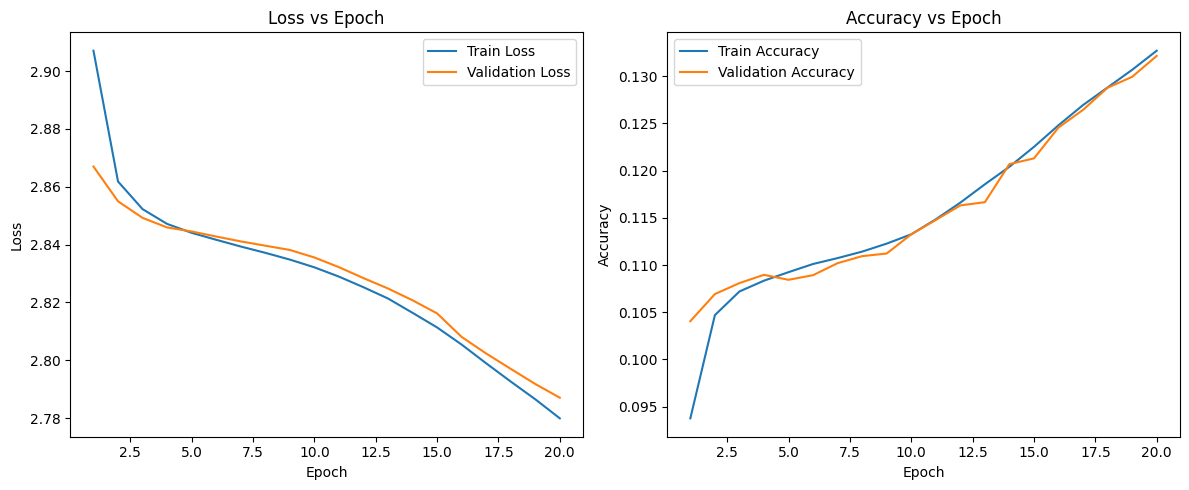

In [ ]:
##Plot Loss and Accuracy
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))

# ---- Loss Plot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# ---- Accuracy Plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluation Metrics


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        preds = torch.argmax(logits, dim=-1)

        # Only consider masked positions
        mask = y_batch != -100
        all_preds.extend(preds[mask].cpu().numpy())
        all_labels.extend(y_batch[mask].cpu().numpy())

In [ ]:
###Checking Predictions
for i in range(15):
  print(f"Pred: {all_preds[i]:2d}   True: {all_labels[i]:2d}   AA:{idx2token[all_preds[i]]}")
#sorted(all_preds)

counts = Counter(all_preds)
print("\nClass frequencies (token index to count):")
for token_idx, count in counts.items():
    print(f"{token_idx:2d}: {count}")

Pred: 14   True: 14   AA:M
Pred: 13   True:  9   AA:L
Pred: 13   True: 21   AA:L
Pred: 13   True: 12   AA:L
Pred: 13   True: 21   AA:L
Pred: 13   True:  8   AA:L
Pred: 13   True: 13   AA:L
Pred: 13   True: 14   AA:L
Pred: 13   True: 13   AA:L
Pred: 13   True: 18   AA:L
Pred: 13   True: 13   AA:L
Pred: 13   True: 24   AA:L
Pred: 13   True: 13   AA:L
Pred: 13   True: 13   AA:L
Pred: 13   True: 16   AA:L

Class frequencies (token index to count):
14: 970
13: 117190
 7: 5304
18: 1296
12: 5509
 3: 44633
11: 7101
19: 4161
 9: 16097
15: 90
10: 118
 6: 1074
20: 789
21: 5449
24: 220
16: 1682
17: 209
 8: 242
 5: 1251
22: 13


In [ ]:
# Overall
acc   = accuracy_score  (all_labels, all_preds)
prec  = precision_score (all_labels, all_preds, average='macro', zero_division=0)
rec   = recall_score    (all_labels, all_preds, average='macro', zero_division=0)
f1    = f1_score        (all_labels, all_preds, average='macro', zero_division=0)

print("=== Overall Metrics ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")

=== Overall Metrics ===
Accuracy:  0.1322
Precision: 0.3312
Recall:    0.0855
F1 score:  0.0805


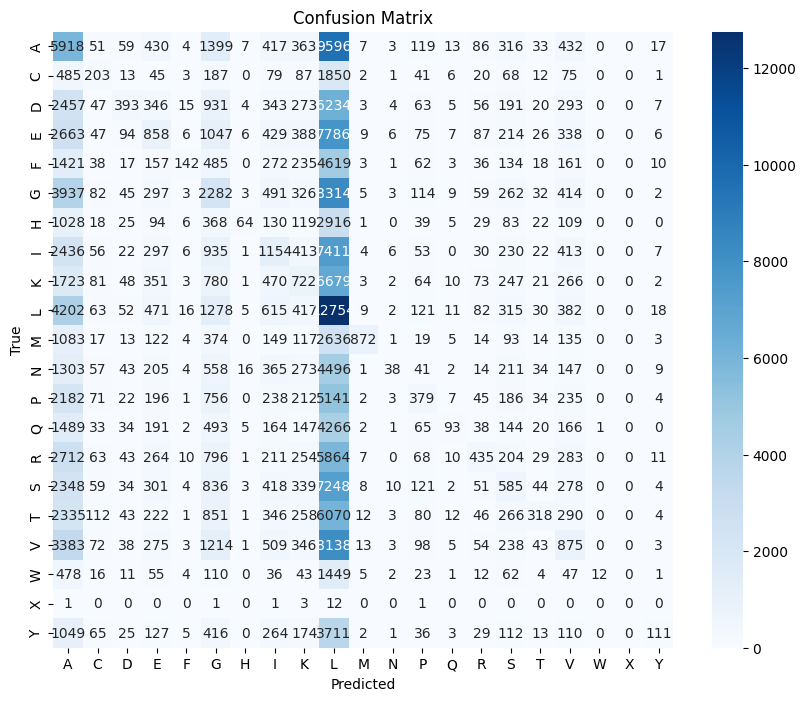

In [ ]:
##Confusion Matrix
classes = np.unique(all_labels)  # sorted array of token indices
cm = confusion_matrix(all_labels, all_preds, labels=classes)
class_names = [list(token2idx.keys())[list(token2idx.values()).index(c)] for c in classes]

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()